In [ ]:
import pandas as pd
import numpy as np


In [ ]:
data=pd.read_csv('/content/data.csv')

In [ ]:
data

,ad_id,type,price,area,bedrooms,bathrooms,level,furnished,rent,city,region
0,Ad id 194281336,apartment,3790000.0,207.0,3,3,2,NaN,no,giza,6th of october
1,Ad id 194198684,apartment,870000.0,155.0,3,3,4,no,no,cairo,new heliopolis
2,Ad id 191102186,apartment,1546400.0,170.0,3,2,9,NaN,no,cairo,zahraa al maadi
3,Ad id 193951860,apartment,1300000.0,270.0,4,3,ground,no,no,sharqia,10th of ramadan
4,Ad id 194064010,duplex,5888000.0,387.0,4,4,ground,no,no,cairo,new cairo - el tagamoa
...,...,...,...,...,...,...,...,...,...,...,...
54324,Ad id 193833696,apartment,18000.0,220.0,2,3,2,yes,yes,alexandria,kafr abdo
54325,Ad id 193833574,apartment,200.0,70.0,1,1,1,yes,yes,alexandria,mandara
54326,Ad id 186376403,apartment,2500.0,80.0,2,1,ground,no,yes,alexandria,miami
54327,Ad id 193831871,apartment,14000.0,200.0,3,2,10+,yes,yes,alexandria,al ibrahimiyyah


## **Data Cleaning **

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54329 entries, 0 to 54328
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ad_id      54329 non-null  object 
 1   type       54329 non-null  object 
 2   price      54329 non-null  float64
 3   area       54329 non-null  float64
 4   bedrooms   54329 non-null  object 
 5   bathrooms  54329 non-null  object 
 6   level      54329 non-null  object 
 7   furnished  42448 non-null  object 
 8   rent       54329 non-null  object 
 9   city       54329 non-null  object 
 10  region     54329 non-null  object 
dtypes: float64(2), object(9)
memory usage: 4.6+ MB


In [ ]:
data.isnull().sum()

,0
ad_id,0
type,0
price,0
area,0
bedrooms,0
bathrooms,0
level,0
furnished,11881
rent,0
city,0


In [ ]:
duplicates = data[data.duplicated()]
duplicates

,ad_id,type,price,area,bedrooms,bathrooms,level,furnished,rent,city,region
15619,Ad id 194199658,apartment,780000.0,130.0,3,2,3,no,no,giza,hadayek al-ahram
15620,Ad id 194304726,apartment,4000000.0,171.0,3,2,7,no,no,alexandria,smoha
15621,Ad id 194315592,apartment,2900000.0,137.0,2,2,2,no,no,cairo,mostakbal city
15622,Ad id 194289013,apartment,2885200.0,147.0,2,2,5,no,no,cairo,new cairo - el tagamoa
15623,Ad id 192153664,apartment,2400000.0,197.0,3,2,1,no,no,cairo,new cairo - el tagamoa
...,...,...,...,...,...,...,...,...,...,...,...
53650,Ad id 194186535,apartment,2750000.0,135.0,2,1,5,yes,no,alexandria,glim
53654,Ad id 194187746,apartment,2850000.0,160.0,2,2,3,yes,no,alexandria,miami
53658,Ad id 194187474,apartment,2080000.0,109.0,2,2,3,no,no,alexandria,smoha
53716,Ad id 191302240,apartment,2850000.0,320.0,4,2,3,NaN,no,alexandria,laurent


In [ ]:
duplicates = data[data.duplicated()]
print(duplicates)


                 ad_id       type      price   area bedrooms bathrooms level  \
15619  Ad id 194199658  apartment   780000.0  130.0        3         2     3   
15620  Ad id 194304726  apartment  4000000.0  171.0        3         2     7   
15621  Ad id 194315592  apartment  2900000.0  137.0        2         2     2   
15622  Ad id 194289013  apartment  2885200.0  147.0        2         2     5   
15623  Ad id 192153664  apartment  2400000.0  197.0        3         2     1   
...                ...        ...        ...    ...      ...       ...   ...   
53650  Ad id 194186535  apartment  2750000.0  135.0        2         1     5   
53654  Ad id 194187746  apartment  2850000.0  160.0        2         2     3   
53658  Ad id 194187474  apartment  2080000.0  109.0        2         2     3   
53716  Ad id 191302240  apartment  2850000.0  320.0        4         2     3   
54211  Ad id 193866800  apartment     5500.0   90.0        2         1     6   

      furnished rent        city       

In [ ]:
sample_duplicates = duplicates.sample(n=10)
sample_duplicates

,ad_id,type,price,area,bedrooms,bathrooms,level,furnished,rent,city,region
44473,Ad id 194366518,apartment,4262000.0,375.0,3,2,highest,NaN,no,alexandria,smoha
39674,Ad id 194178493,studio,28000.0,94.0,1,1,ground,yes,yes,cairo,new cairo - el tagamoa
19232,Ad id 191737065,apartment,1450000.0,177.0,3,3,2,NaN,no,cairo,new cairo - el tagamoa
52466,Ad id 194289490,apartment,290000.0,90.0,2,1,4,no,no,alexandria,nakheel
30771,Ad id 194281960,apartment,1400000.0,265.0,3,3,ground,NaN,no,cairo,new cairo - el tagamoa
17518,Ad id 193725932,apartment,900000.0,135.0,3,1,6,NaN,no,cairo,mokattam
17203,Ad id 194344329,apartment,20000.0,207.0,3,3,2,no,yes,cairo,new cairo - el tagamoa
15738,Ad id 194366851,apartment,565000.0,115.0,3,1,3,no,no,cairo,new cairo - el tagamoa
35360,Ad id 194285544,apartment,13000.0,297.0,3,3,3,no,yes,giza,sheikh zayed
41775,Ad id 194319540,apartment,4185000.0,135.0,3,3,1,no,no,giza,sheikh zayed


In [ ]:
data_cleaned = data.drop_duplicates(keep='first')

In [ ]:
duplicate=data_cleaned.duplicated()
duplicate.sum()

np.int64(0)

In [ ]:
data.shape

(54329, 11)

In [ ]:
data_cleaned.dropna()

,ad_id,type,price,area,bedrooms,bathrooms,level,furnished,rent,city,region
1,Ad id 194198684,apartment,870000.0,155.0,3,3,4,no,no,cairo,new heliopolis
3,Ad id 193951860,apartment,1300000.0,270.0,4,3,ground,no,no,sharqia,10th of ramadan
4,Ad id 194064010,duplex,5888000.0,387.0,4,4,ground,no,no,cairo,new cairo - el tagamoa
5,Ad id 194021448,apartment,950000.0,104.0,2,1,7,no,no,cairo,nasr city
6,Ad id 194294715,apartment,2100000.0,160.0,3,2,1,no,no,cairo,mostakbal city
...,...,...,...,...,...,...,...,...,...,...,...
54324,Ad id 193833696,apartment,18000.0,220.0,2,3,2,yes,yes,alexandria,kafr abdo
54325,Ad id 193833574,apartment,200.0,70.0,1,1,1,yes,yes,alexandria,mandara
54326,Ad id 186376403,apartment,2500.0,80.0,2,1,ground,no,yes,alexandria,miami
54327,Ad id 193831871,apartment,14000.0,200.0,3,2,10+,yes,yes,alexandria,al ibrahimiyyah


In [ ]:
data_cleaned.isnull().sum()

,0
ad_id,0
type,0
price,0
area,0
bedrooms,0
bathrooms,0
level,0
furnished,4613
rent,0
city,0


In [ ]:
data_cleaned['furnished'] = data_cleaned['furnished'].str.strip()


<ipython-input-14-c8d3549ad09f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['furnished'] = data_cleaned['furnished'].str.strip()


In [ ]:
data_cleaned.replace("", np.nan, inplace=True)
data_cleaned.replace("None", np.nan, inplace=True)
data_cleaned.dropna(inplace=True)


<ipython-input-15-d1db3413f099>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned.replace("", np.nan, inplace=True)
<ipython-input-15-d1db3413f099>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned.replace("None", np.nan, inplace=True)
<ipython-input-15-d1db3413f099>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned.dropna(inplace=True)


In [ ]:
print(data_cleaned['furnished'].unique())


['no' 'yes']


In [ ]:
print(data_cleaned.isnull().sum())


ad_id        0
type         0
price        0
area         0
bedrooms     0
bathrooms    0
level        0
furnished    0
rent         0
city         0
region       0
dtype: int64


In [ ]:
!pip install ydata_profiling


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 79.2 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=d46a89fdcb6de5acb6782f7591f48d493de9d83aee42083acb31af17f2954220
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin


In [ ]:
data_cleaned

,ad_id,type,price,area,bedrooms,bathrooms,level,furnished,rent,city,region
1,Ad id 194198684,apartment,870000.0,155.0,3,3,4,no,no,cairo,new heliopolis
3,Ad id 193951860,apartment,1300000.0,270.0,4,3,ground,no,no,sharqia,10th of ramadan
4,Ad id 194064010,duplex,5888000.0,387.0,4,4,ground,no,no,cairo,new cairo - el tagamoa
5,Ad id 194021448,apartment,950000.0,104.0,2,1,7,no,no,cairo,nasr city
6,Ad id 194294715,apartment,2100000.0,160.0,3,2,1,no,no,cairo,mostakbal city
...,...,...,...,...,...,...,...,...,...,...,...
54324,Ad id 193833696,apartment,18000.0,220.0,2,3,2,yes,yes,alexandria,kafr abdo
54325,Ad id 193833574,apartment,200.0,70.0,1,1,1,yes,yes,alexandria,mandara
54326,Ad id 186376403,apartment,2500.0,80.0,2,1,ground,no,yes,alexandria,miami
54327,Ad id 193831871,apartment,14000.0,200.0,3,2,10+,yes,yes,alexandria,al ibrahimiyyah


In [ ]:
data_cleaned['level'] = data_cleaned['level'].replace({'ground': 0})

<ipython-input-21-9ba190ed26e4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['level'] = data_cleaned['level'].replace({'ground': 0})


In [ ]:
data_cleaned

,ad_id,type,price,area,bedrooms,bathrooms,level,furnished,rent,city,region
1,Ad id 194198684,apartment,870000.0,155.0,3,3,4,no,no,cairo,new heliopolis
3,Ad id 193951860,apartment,1300000.0,270.0,4,3,0,no,no,sharqia,10th of ramadan
4,Ad id 194064010,duplex,5888000.0,387.0,4,4,0,no,no,cairo,new cairo - el tagamoa
5,Ad id 194021448,apartment,950000.0,104.0,2,1,7,no,no,cairo,nasr city
6,Ad id 194294715,apartment,2100000.0,160.0,3,2,1,no,no,cairo,mostakbal city
...,...,...,...,...,...,...,...,...,...,...,...
54324,Ad id 193833696,apartment,18000.0,220.0,2,3,2,yes,yes,alexandria,kafr abdo
54325,Ad id 193833574,apartment,200.0,70.0,1,1,1,yes,yes,alexandria,mandara
54326,Ad id 186376403,apartment,2500.0,80.0,2,1,0,no,yes,alexandria,miami
54327,Ad id 193831871,apartment,14000.0,200.0,3,2,10+,yes,yes,alexandria,al ibrahimiyyah


In [ ]:
data_cleaned['ad_id'] = data_cleaned['ad_id'].str.extract(r'(\d+)').astype(int)


<ipython-input-23-4ebd7c7648d3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['ad_id'] = data_cleaned['ad_id'].str.extract(r'(\d+)').astype(int)


In [ ]:
data_cleaned

,ad_id,type,price,area,bedrooms,bathrooms,level,furnished,rent,city,region
1,194198684,apartment,870000.0,155.0,3,3,4,no,no,cairo,new heliopolis
3,193951860,apartment,1300000.0,270.0,4,3,0,no,no,sharqia,10th of ramadan
4,194064010,duplex,5888000.0,387.0,4,4,0,no,no,cairo,new cairo - el tagamoa
5,194021448,apartment,950000.0,104.0,2,1,7,no,no,cairo,nasr city
6,194294715,apartment,2100000.0,160.0,3,2,1,no,no,cairo,mostakbal city
...,...,...,...,...,...,...,...,...,...,...,...
54324,193833696,apartment,18000.0,220.0,2,3,2,yes,yes,alexandria,kafr abdo
54325,193833574,apartment,200.0,70.0,1,1,1,yes,yes,alexandria,mandara
54326,186376403,apartment,2500.0,80.0,2,1,0,no,yes,alexandria,miami
54327,193831871,apartment,14000.0,200.0,3,2,10+,yes,yes,alexandria,al ibrahimiyyah


In [ ]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16914 entries, 1 to 54328
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ad_id      16914 non-null  int64  
 1   type       16914 non-null  object 
 2   price      16914 non-null  float64
 3   area       16914 non-null  float64
 4   bedrooms   16914 non-null  object 
 5   bathrooms  16914 non-null  object 
 6   level      16914 non-null  object 
 7   furnished  16914 non-null  object 
 8   rent       16914 non-null  object 
 9   city       16914 non-null  object 
 10  region     16914 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 2.1+ MB


In [ ]:
data_cleaned.columns

Index(['ad_id', 'type', 'price', 'area', 'bedrooms', 'bathrooms', 'level',
       'furnished', 'rent', 'city', 'region'],
      dtype='object')

In [ ]:
data_cleaned.columns = data_cleaned.columns.str.strip()

In [ ]:
data_cleaned['bedrooms'] = pd.to_numeric(data_cleaned['bedrooms'], errors='coerce')
data_cleaned['level'] = pd.to_numeric(data_cleaned['level'], errors='coerce')


<ipython-input-28-df8e4b08b2d4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['bedrooms'] = pd.to_numeric(data_cleaned['bedrooms'], errors='coerce')
<ipython-input-28-df8e4b08b2d4>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['level'] = pd.to_numeric(data_cleaned['level'], errors='coerce')


In [ ]:
import matplotlib.pyplot as plt


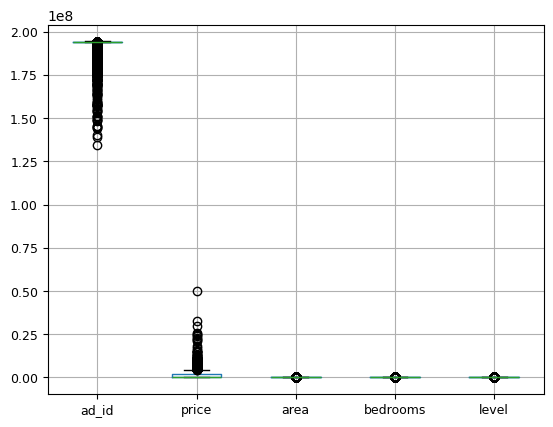

In [ ]:
numerical_columns=['ad_id','price','area','bedrooms','level']

boxplot =data_cleaned.boxplot(column=numerical_columns, grid=True, fontsize=9)
plt.show()

In [ ]:
import numpy as np

# Define thresholds
lower_bound = data_cleaned['price'].quantile(0.05)  # 5th percentile
upper_bound = data_cleaned['price'].quantile(0.95)  # 95th percentile

# Cap outliers
data_cleaned['price'] = np.clip(data_cleaned['price'], lower_bound, upper_bound)


<ipython-input-31-44d915998146>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['price'] = np.clip(data_cleaned['price'], lower_bound, upper_bound)


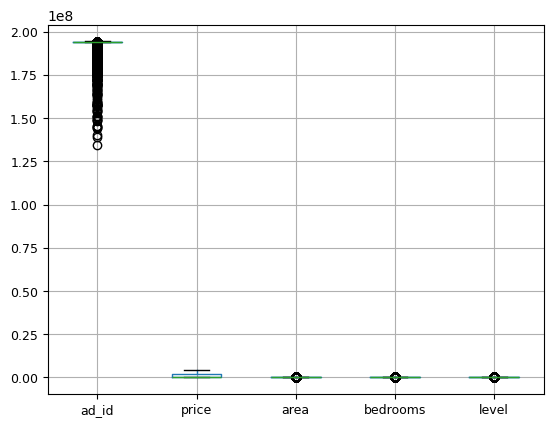

In [ ]:
boxplot =data_cleaned.boxplot(column=numerical_columns, grid=True, fontsize=9)
plt.show()

In [ ]:
data_cleaned

,ad_id,type,price,area,bedrooms,bathrooms,level,furnished,rent,city,region
1,194198684,apartment,870000.0,155.0,3.0,3,4.0,no,no,cairo,new heliopolis
3,193951860,apartment,1300000.0,270.0,4.0,3,0.0,no,no,sharqia,10th of ramadan
4,194064010,duplex,4500000.0,387.0,4.0,4,0.0,no,no,cairo,new cairo - el tagamoa
5,194021448,apartment,950000.0,104.0,2.0,1,7.0,no,no,cairo,nasr city
6,194294715,apartment,2100000.0,160.0,3.0,2,1.0,no,no,cairo,mostakbal city
...,...,...,...,...,...,...,...,...,...,...,...
54324,193833696,apartment,18000.0,220.0,2.0,3,2.0,yes,yes,alexandria,kafr abdo
54325,193833574,apartment,2500.0,70.0,1.0,1,1.0,yes,yes,alexandria,mandara
54326,186376403,apartment,2500.0,80.0,2.0,1,0.0,no,yes,alexandria,miami
54327,193831871,apartment,14000.0,200.0,3.0,2,NaN,yes,yes,alexandria,al ibrahimiyyah


In [ ]:
data_cleaned['level'].unique()

array([ 4.,  0.,  7.,  1.,  3.,  2.,  6.,  5., 10., nan,  8.,  9.])

In [ ]:
data_cleaned.isnull().sum()

,0
ad_id,0
type,0
price,0
area,0
bedrooms,6
bathrooms,0
level,555
furnished,0
rent,0
city,0


In [ ]:
data_cleaned['level'].replace(["", "None"], np.nan, inplace=True)
data_cleaned.dropna(subset=['level'], inplace=True)
data_cleaned['bedrooms'].replace(["", "None"], np.nan, inplace=True)
data_cleaned.dropna(subset=['bedrooms'], inplace=True)


<ipython-input-36-6e2b2a50acea>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned['level'].replace(["", "None"], np.nan, inplace=True)
<ipython-input-36-6e2b2a50acea>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['level'].replace(["", "None"], np.nan, inplace=True)
<ipython-input-36-6e2b2a50acea>:2: SettingWithCopyW

In [ ]:
data_cleaned.isnull().sum()

,0
ad_id,0
type,0
price,0
area,0
bedrooms,0
bathrooms,0
level,0
furnished,0
rent,0
city,0


In [ ]:
data_cleaned['type'].unique()

array(['apartment', 'duplex', 'penthouse', 'studio', 'room'], dtype=object)

In [ ]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16354 entries, 1 to 54326
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ad_id      16354 non-null  int64  
 1   type       16354 non-null  object 
 2   price      16354 non-null  float64
 3   area       16354 non-null  float64
 4   bedrooms   16354 non-null  float64
 5   bathrooms  16354 non-null  object 
 6   level      16354 non-null  float64
 7   furnished  16354 non-null  object 
 8   rent       16354 non-null  object 
 9   city       16354 non-null  object 
 10  region     16354 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 1.5+ MB


In [ ]:
data_cleaned['bathrooms'].unique()

array(['3', '4', '1', '2', '5', '9', '6', '10+', '7'], dtype=object)

In [ ]:
data_cleaned['bathrooms'] = data_cleaned['bathrooms'].replace({'10+': 10}).astype(int)


<ipython-input-41-c2c6e1325c8c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['bathrooms'] = data_cleaned['bathrooms'].replace({'10+': 10}).astype(int)


In [ ]:
data_cleaned['bedrooms'] = pd.to_numeric(data_cleaned['bedrooms'], errors='coerce').fillna(0).astype(int)


<ipython-input-42-0a7eac40402d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['bedrooms'] = pd.to_numeric(data_cleaned['bedrooms'], errors='coerce').fillna(0).astype(int)


In [ ]:
data_cleaned.shape

(42432, 11)

In [ ]:
data_cleaned = data.drop_duplicates(keep='first')

In [ ]:
data_cleaned.shape

(21527, 11)

In [ ]:
data_cleaned.duplicated().sum()

np.int64(0)

# Data Vlidation:

In [ ]:
!pip install pandera
import pandera as pa
import pandas as pd
from pandera import Column, DataFrameSchema, Check, Index

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.2/264.2 kB 5.7 MB/s eta 0:00:00


In [ ]:
import pandera as pa

schema = pa.DataFrameSchema({
    "price": pa.Column(float, pa.Check(lambda x: x >= 0)),  # Price must be non-negative
    "area": pa.Column(float, pa.Check.in_range(1, 1000)),  # Area range
    "bathrooms": pa.Column(int, pa.Check.in_range(1, 10)),  # Bathrooms between 1 and 10
    "bedrooms": pa.Column(int, pa.Check(lambda x: x > 0)),  # Bedrooms must be positive
    "ad_id": pa.Column(int, pa.Check(lambda x: x > 0)),  # Ad ID must be valid
    "type": pa.Column(str, pa.Check.isin(["apartment", "duplex", "penthouse", "studio", "room"])),  # Property types
    "level": pa.Column(float, pa.Check(lambda x: x >= 0)),  # Level must be non-negative
    "furnished": pa.Column(str, pa.Check.isin(["yes", "no"])),  # Only 'yes' or 'no' allowed
    "rent": pa.Column(str, pa.Check.isin(["yes", "no"])),  # Only 'yes' or 'no' allowed
    "city": pa.Column(str),  # Check if city names exist
    "region": pa.Column(str)  # Ensure region is valid
})

validated_data = schema.validate(data_cleaned)
print(validated_data.head())


/usr/local/lib/python3.11/dist-packages/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


       ad_id       type      price   area  bedrooms  bathrooms  level  \
1  194198684  apartment   870000.0  155.0         3          3    4.0   
3  193951860  apartment  1300000.0  270.0         4          3    0.0   
4  194064010     duplex  4500000.0  387.0         4          4    0.0   
5  194021448  apartment   950000.0  104.0         2          1    7.0   
6  194294715  apartment  2100000.0  160.0         3          2    1.0   

  furnished rent     city                  region  
1        no   no    cairo          new heliopolis  
3        no   no  sharqia         10th of ramadan  
4        no   no    cairo  new cairo - el tagamoa  
5        no   no    cairo               nasr city  
6        no   no    cairo          mostakbal city  


In [ ]:
!pip install pandera[io]

import pandera as pa
from pandera import Column, DataFrameSchema, Check, Index
inferred_schema = pa.infer_schema(data_cleaned).to_script()
print(inferred_schema)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.8/420.8 kB 8.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.1 MB/s eta 0:00:00
  Created wheel for petl: filename=petl-1.7.16-py3-none-any.whl size=231358 sha256=0ce958805e9287abf5f55654bfdafc324bca1ad230a39becdb2f557cbd4a00d5
  Stored in directory: /root/.cache/pip/wheels/eb/95/ae/3c6facfef5253baf2f3f52be921376fbebbc83526894533d46
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3567 sha256=16

In [ ]:
!pip install great_expectations
import great_expectations as gx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 813.6/813.6 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.1/739.1 kB 28.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled 

In [ ]:
context = gx.get_context()


INFO:great_expectations.data_context.types.base:Created temporary directory '/tmp/tmpmenijo5b' for ephemeral docs site


In [ ]:
print(context.list_datasources())


[]


In [ ]:
data_cleaned = pd.read_csv('/content/data.csv')


In [ ]:
data_cleaned['bathrooms'] = pd.to_numeric(data_cleaned['bathrooms'], errors='coerce').fillna(0).astype(int)


In [ ]:
data_cleaned = data_cleaned[data_cleaned['bathrooms'] >= 1]


In [ ]:
data_cleaned['bedrooms'] = data_cleaned['bedrooms'].replace({'10+': 10}).astype(int)


<ipython-input-52-06e80fc12ea0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['bedrooms'] = data_cleaned['bedrooms'].replace({'10+': 10}).astype(int)


In [ ]:
print(data_cleaned['bedrooms'].dtype)  # Should return int64
print(data_cleaned['bedrooms'].unique())  # Verify values


int64
[ 3  4  2  1  6  5 10  9  7  8]


In [ ]:
data_cleaned

,ad_id,type,price,area,bedrooms,bathrooms,level,furnished,rent,city,region
0,Ad id 194281336,apartment,3790000.0,207.0,3,3,2,NaN,no,giza,6th of october
1,Ad id 194198684,apartment,870000.0,155.0,3,3,4,no,no,cairo,new heliopolis
2,Ad id 191102186,apartment,1546400.0,170.0,3,2,9,NaN,no,cairo,zahraa al maadi
3,Ad id 193951860,apartment,1300000.0,270.0,4,3,ground,no,no,sharqia,10th of ramadan
4,Ad id 194064010,duplex,5888000.0,387.0,4,4,ground,no,no,cairo,new cairo - el tagamoa
...,...,...,...,...,...,...,...,...,...,...,...
54324,Ad id 193833696,apartment,18000.0,220.0,2,3,2,yes,yes,alexandria,kafr abdo
54325,Ad id 193833574,apartment,200.0,70.0,1,1,1,yes,yes,alexandria,mandara
54326,Ad id 186376403,apartment,2500.0,80.0,2,1,ground,no,yes,alexandria,miami
54327,Ad id 193831871,apartment,14000.0,200.0,3,2,10+,yes,yes,alexandria,al ibrahimiyyah


In [ ]:
data_cleaned['ad_id'] = data_cleaned['ad_id'].str.extract(r'(\d+)').astype(int)


In [ ]:
data_cleaned['level'] = data_cleaned['level'].replace({'ground': 0})
# data_cleaned['column_name'] = pd.to_numeric(data_cleaned['column_name'], errors='coerce')  # Convert back to numeric


In [ ]:
import numpy as np

# Replace '10+' and 'highest' with numeric values
data_cleaned['level'] = data_cleaned['level'].replace({'10+': 10, 'highest': 10})

# Convert column to numeric, setting invalid entries to NaN
data_cleaned['level'] = pd.to_numeric(data_cleaned['level'], errors='coerce')

# Optional: Fill missing values (if needed)
data_cleaned['level'].fillna(0, inplace=True)  # Replace NaN with a default (e.g., 0)

# Convert to integer
data_cleaned['level'] = data_cleaned['level'].astype(int)

# Verify unique values after cleaning
print(data_cleaned['level'].unique())


[ 2  4  9  0  7  1  3  6  5 10  8]


<ipython-input-66-3df666e23bd8>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned['level'].fillna(0, inplace=True)  # Replace NaN with a default (e.g., 0)


In [ ]:
schema = pa.DataFrameSchema({
    "level": pa.Column(int, pa.Check(lambda x: x >= 0))  # Ensure non-negative integers
})


In [ ]:
data_cleaned.dropna(subset=['furnished'], inplace=True)


In [ ]:
validated_data = schema.validate(data_cleaned)
print(validated_data.head())


       ad_id       type      price   area  bedrooms  bathrooms  level  \
1  194198684  apartment   870000.0  155.0         3          3      4   
3  193951860  apartment  1300000.0  270.0         4          3      0   
4  194064010     duplex  5888000.0  387.0         4          4      0   
5  194021448  apartment   950000.0  104.0         2          1      7   
6  194294715  apartment  2100000.0  160.0         3          2      1   

  furnished rent     city                  region  
1        no   no    cairo          new heliopolis  
3        no   no  sharqia         10th of ramadan  
4        no   no    cairo  new cairo - el tagamoa  
5        no   no    cairo               nasr city  
6        no   no    cairo          mostakbal city  


In [ ]:
print(data_cleaned.dtypes)


ad_id          int64
type          object
price        float64
area         float64
bedrooms       int64
bathrooms      int64
level          int64
furnished     object
rent          object
city          object
region        object
dtype: object


In [ ]:
from ydata_profiling import ProfileReport
import pandas as pd

profile = ProfileReport(data_cleaned, title="Data Profiling Report")
profile.to_file("report.html")

/usr/local/lib/python3.11/dist-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:01<00:00,  7.23it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]